## REDSEA optimization

The REDSEA algorithm for spillover correction takes some parameters as inputs, namely the size and shape of the structuring element used to classify pixels as border pixels.

In this notebook, we conduct some experiments to evaluate how different structuring elements affect the results of the pipeline.

The metric we will use for evaluation is the number of CD3+/CD20+ double-positive cells. These markers are mutually exclusive, so we want the number of these double-positive cells to be as low as possible. Per Sascha, we should use cutoff values of 200 for CD3e and 600 for CD20 (cells above these thresholds are positive for those markers).

In [1]:
from pathlib import Path
import numpy as np
import copy
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from pathml.core import SlideData, CODEXSlide

from transforms import REDSEAQuantifyMIF, FilterEdgeCells

In [2]:
# load the image
# use already processed image, so we don't need to re-tile
wsi_path = Path("/Users/jacobrosenthal/data/molecular_imaging_core/Exp. 270 - 102521SM-HNC14/processed_2021-10-26/pathml_analysis/redsea2_Exp. 270 - 102521SM-HNC14.h5path")
wsi = SlideData(str(wsi_path))

/opt/miniconda3/envs/codex/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


In [3]:
wsi

SlideData(name='exp270-102521SM-HNC14.ome.tiff',
	slide_type=SlideType(stain=Fluor, platform=CODEX, tma=None, rgb=None, volumetric=None, time_series=None),
	filepath='/Users/jacobrosenthal/data/molecular_imaging_core/Exp. 270 - 102521SM-HNC14/processed_2021-10-26/pathml_analysis/redsea2_Exp. 270 - 102521SM-HNC14.h5path',
	backend='h5path',
	image shape: (11264, 11264),
	number of levels: 1,
	196 tiles: ['(0, 0)', '(0, 10712)', '(0, 1648)', '(0, 2472)', '(0, 3296)', '(0, 4120)', ...],
	0 masks: [],
	tile_shape=(1024, 1024, 72),
	labels=None,
	counts matrix of shape (189075, 72))

In [4]:
# load channels
channel_list = pd.read_csv("/Users/jacobrosenthal/data/molecular_imaging_core/Exp. 270 - 102521SM-HNC14/processed_2021-10-26/pathml_analysis/redsea2_Exp. 270 - 102521SM-HNC14_h5path_channel_order.txt",
                           sep='\t', header=None, index_col=0)
channel_list = list(channel_list[1].values)

cd3e_ix = channel_list.index('CD3e')
cd20_ix = channel_list.index('CD20')

cd3e_threshold = 200
cd20_threshold = 600

print("marker", "index", "threshold", sep = "\t")
print("CD3e", cd3e_ix, cd3e_threshold, sep = "\t")
print("CD20", cd20_ix, cd20_threshold, sep = "\t")

marker	index	threshold
CD3e	46	200
CD20	70	600


In [11]:
# parameters to search over
elem_shapes = ["diamond", "disk", "square", "star"]
elem_sizes = [2, 3, 4, 5, 6]

# matrix to store counts of doublepositive cells
cd3cd20_doublepos = np.zeros((len(elem_sizes), len(elem_shapes)))

In [12]:
# initialize edge filter outside loop, since it's the same for everything
edge_filter = FilterEdgeCells(edge_distance = 100, slide_shape = wsi.shape)

# loop through tiles
for t in tqdm(wsi.tiles):
    
    # select for tiles in region of interest outlined by Sascha:
    if not ((2400 < t.coords[0] < 3700) and (1600 < t.coords[1] < 4500)):
        continue
    
    # convert to correct datatype after retrieving from h5
    for m in t.masks.keys():
        t.masks[m] = t.masks[m].astype(np.int32)
    t.image = t.image.astype(np.float32)
    
    # grid search over redsea parameters
    for i, elem_size in enumerate(elem_sizes):
        for j, elem_shape in enumerate(elem_shapes):
            
            # initialize the transforms
            redsea = REDSEAQuantifyMIF(segmentation_mask="watershed", element_shape=elem_shape, element_size = elem_size)
            
            # apply transforms
            redsea.apply(t)
            edge_filter.apply(t)
            
            # count number of double positive cells
            n_double_positive = np.logical_and(
                t.counts.X[:, cd3e_ix] > cd3e_threshold, 
                t.counts.X[:, cd20_ix] > cd20_threshold
            ).sum()
            
            # add to matrix
            cd3cd20_doublepos[i, j] += n_double_positive
            
            # reset the tile's counts just in case
            t.counts = None

  0%|          | 0/196 [00:00<?, ?it/s]

/Users/jacobrosenthal/PycharmProjects/CODEX-custom-pipeline/pathml_workflow/transforms.py:299: RuntimeWarning: invalid value encountered in matmul
  counts_redsea = np.diag([1 / cell_size for cell_size in cell_sizes]) @ counts_redsea
/Users/jacobrosenthal/PycharmProjects/CODEX-custom-pipeline/pathml_workflow/transforms.py:293: RuntimeWarning: invalid value encountered in matmul
  counts_subtract = cell_pair_weights @ counts_border
/Users/jacobrosenthal/PycharmProjects/CODEX-custom-pipeline/pathml_workflow/transforms.py:299: RuntimeWarning: invalid value encountered in matmul
  counts_redsea = np.diag([1 / cell_size for cell_size in cell_sizes]) @ counts_redsea
/Users/jacobrosenthal/PycharmProjects/CODEX-custom-pipeline/pathml_workflow/transforms.py:293: RuntimeWarning: invalid value encountered in matmul
  counts_subtract = cell_pair_weights @ counts_border
/Users/jacobrosenthal/PycharmProjects/CODEX-custom-pipeline/pathml_workflow/transforms.py:299: RuntimeWarning: invalid value encou

In [13]:
cd3cd20_doublepos

array([[2.404e+03, 2.065e+03, 1.746e+03, 1.404e+03],
       [1.069e+03, 8.490e+02, 6.810e+02, 5.010e+02],
       [3.660e+02, 2.450e+02, 1.210e+02, 5.600e+01],
       [2.400e+01, 1.100e+01, 5.000e+00, 2.000e+00],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]])

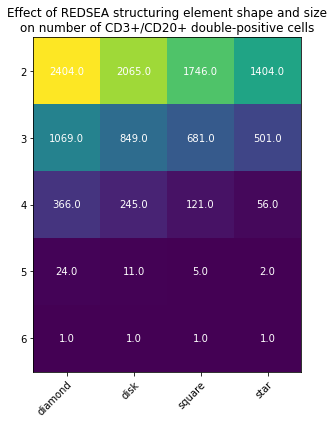

In [23]:
fig, ax = plt.subplots(figsize = (6, 6))
im = ax.imshow(cd3cd20_doublepos)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(elem_shapes)), labels=elem_shapes)
ax.set_yticks(np.arange(len(elem_sizes)), labels=elem_sizes)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(elem_sizes)):
    for j in range(len(elem_shapes)):
        text = ax.text(j, i, cd3cd20_doublepos[i, j],
                       ha="center", va="center", color="w")

ax.set_title("Effect of REDSEA structuring element shape and size\non number of CD3+/CD20+ double-positive cells")
fig.tight_layout()
plt.show()

From the above results we can rule out kernels of size 4 and greater - the number of double positive cells in those
cases is so low that it is most likely removing the real signal in additoin to the spillover signal (i.e., overly
aggressive correction).

Note: I'm also a bit suspicious why the numbers are strictly decreasing in each row from left to right - this
seems too perfect to be a naturally arising pattern, could be from a bug in the code.

Next person looking at this notebook should investigate